# Modelo CNN simples
#### MNIST Fashion dataset

Fashion-MNIST é um conjunto de dados de imagens de artigos de moda, consistindo em um conjunto de treinamento de 60.000 exemplos e um conjunto de teste de 10.000 exemplos.

Cada exemplo é uma imagem em tons de cinza de 28x28, associada a um rótulo de 10 classes. Ele compartilha o mesmo tamanho de imagem e estrutura de divisões de treinamento e teste.

##### Descrição dos dados

Cada imagem tem 28 pixels de altura e 28 pixels de largura, totalizando 784 pixels.
Cada pixel tem um único valor de pixel associado a ele, indicando a claridade ou escuridão daquele pixel, com números mais altos significando mais escuro. Este valor de pixel é um inteiro entre 0 e 255.
Os conjuntos de dados de treinamento e teste têm 785 colunas.
A primeira coluna consiste nos rótulos de classe e representa o artigo de vestuário.

##### Rótulos
Cada exemplo de treinamento e teste é atribuído a um dos rótulos:

0. Camiseta/top
1. Calça
2. Pulôver
3. Vestido
4. Casaco
5. Sandália
6. Camisa
7. Tênis
8. Bolsa
9. Bota de cano curto

In [ ]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import keras
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten,Dropout
from keras.optimizers import Adam
from keras.callbacks import TensorBoard

import tensorflow as tf
print("GPU disponível:", tf.config.list_physical_devices('GPU'))

num_classes = 10
epochs = 20

GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#### Explicação:
- `pandas` e `numpy`: Para manipulação e processamento de dados estruturados e numéricos.
- `warnings.filterwarnings('ignore')`: Supressão de avisos para tornar a saída do notebook mais limpa.
- `matplotlib.pyplot`: Biblioteca para visualização gráfica.
- `train_test_split`: Utilizado para dividir os dados em conjuntos de treinamento e validação.
- Keras:
  - `Sequential`: Modelo básico para empilhar camadas sequencialmente.
  - `Conv2D`, `MaxPooling2D`, `Dense`, `Flatten`, `Dropout`: Camadas essenciais para CNNs.
  - `Adam`: Otimizador amplamente usado em CNNs.
  - `TensorBoard`: Callback para visualizar métricas do modelo durante o treinamento.

# Carregar os dados

In [ ]:
train_df = pd.read_csv('mnist_train.csv',sep=',', header=None)
test_df = pd.read_csv('mnist_test.csv', sep = ',', header=None)
train_df.shape

(60000, 785)

In [ ]:
# Renomeando o dataframe
columns = ['label'] + [f'pixel{i}' for i in range(train_df.shape[1]-1)]
train_df.columns = columns
test_df.columns = columns

In [ ]:
train_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,119,114,130,76,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,33,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
test_df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,2,3,0,3,174,189,67,0,0,0
2,1,0,0,0,0,0,0,0,0,1,...,164,58,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,6,0,0,0,2,0,1,1,0,0,...,71,12,0,0,0,0,0,0,0,0


#### Explicação:
- `pd.read_csv()`: Lê os arquivos CSV do conjunto de dados de treino e teste.
- `header=None`: Indica que não há cabeçalho nas colunas dos arquivos.



In [ ]:
train_data = np.array(train_df, dtype = 'float32')
test_data = np.array(test_df, dtype='float32')

In [ ]:
x_train = train_data[:,1:]/255

y_train = train_data[:,0]

x_test= test_data[:,1:]/255

y_test=test_data[:,0]

In [ ]:
x_train,x_validate,y_train,y_validate = train_test_split(x_train,y_train,test_size = 0.2,random_state = 12345)

#### Explicação:
- Converte os DataFrames para arrays `numpy`, uma estrutura mais eficiente para operações matriciais.
- Normalização (`x_train[:, 1:] / 255`): Converte os valores dos pixels de 0-255 para 0-1, melhorando a estabilidade do treinamento.
- Separação dos rótulos (`y_train`) e imagens (`x_train`).
- `train_test_split`: Divide os dados de treino em 80% para treino e 20% para validação.


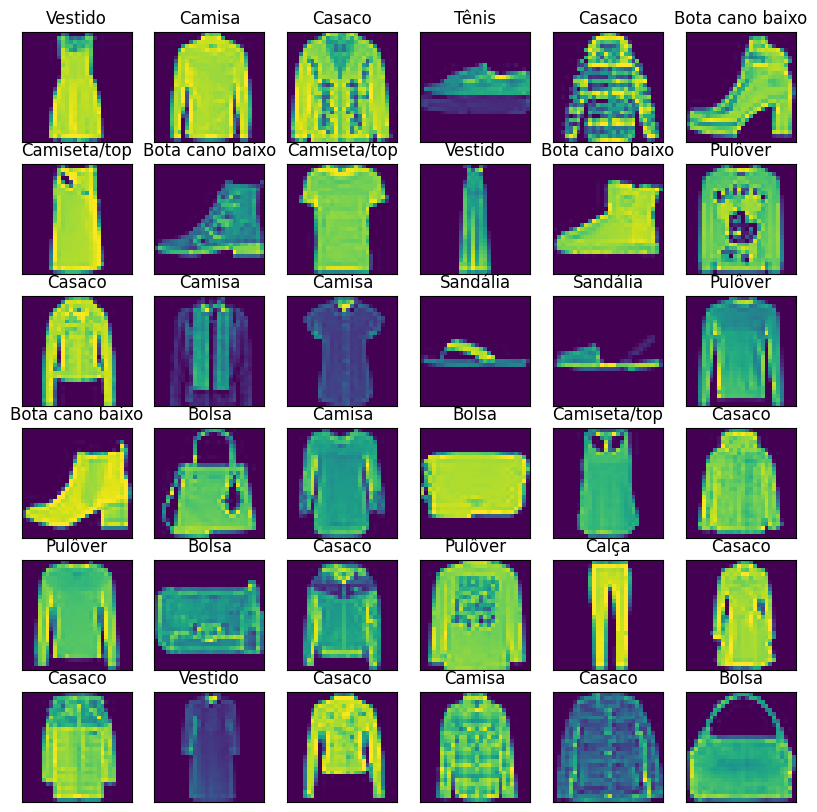

In [ ]:
class_names = ['Camiseta/top', 'Calça', 'Pulôver', 'Vestido', 'Casaco',
               'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota cano baixo']
plt.figure(figsize=(10, 10))
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i].reshape((28,28)))
    label_index = int(y_train[i])
    plt.title(class_names[label_index])
plt.show()

#### Explicação:
- Plota as primeiras 36 imagens com seus respectivos rótulos.

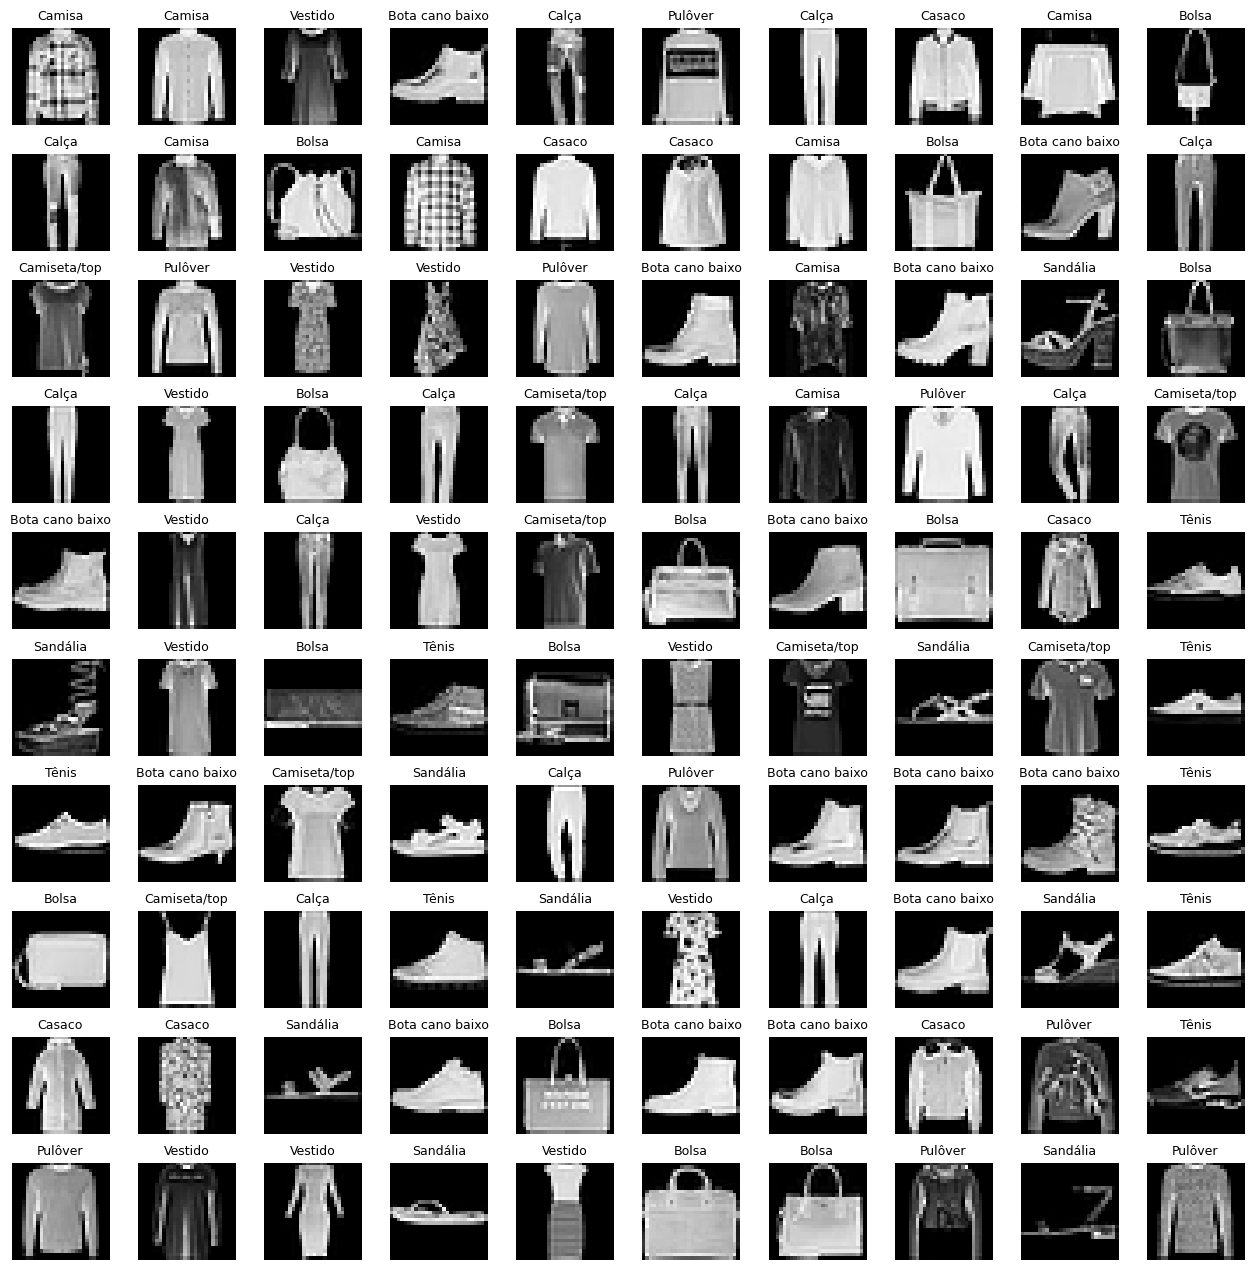

In [ ]:
W_grid = 10
L_grid = 10

fig, axes = plt.subplots(L_grid, W_grid, figsize = (16,16))
axes = axes.ravel()
n_train = len(train_data) # get the length of the train dataset

# Select a random number from 0 to 100
for i in range(min(100, n_train)):
    # Select a random number
    index = np.random.randint(0, n_train)
    # read and display an image with the selected index
    axes[i].imshow(train_data[index, 1:].reshape((28, 28)), cmap='gray')
    labelindex = int(train_data[index,0])
    axes[i].set_title(class_names[labelindex], fontsize = 9)
    axes[i].axis('off')

plt.subplots_adjust(hspace=0.3)

#### Explicação:
- **Estrutura do Grid:** Cria um layout de 15x15 subplots.
- **Seleção Aleatória:** Mostra imagens aleatórias do conjunto de dados.
- **Visualização:** Ajusta os espaçamentos entre subplots para clareza.


## Modelo CNN

In [ ]:
image_rows = 28
image_cols = 28
batch_size = 4096
image_shape = (image_rows,image_cols,1)

In [ ]:
x_train = x_train.reshape(x_train.shape[0],*image_shape)
x_test = x_test.reshape(x_test.shape[0],*image_shape)
x_validate = x_validate.reshape(x_validate.shape[0],*image_shape)

#### Explicação:
- **Dimensão das imagens:** Define a forma `(28, 28, 1)` para indicar imagens em escala de cinza.
- **Reshape:** Ajusta as entradas para o formato esperado pela camada `Conv2D` (batch size, altura, largura, canais).
- **Uso do Asterisco:** `*image_shape` expande a tupla `(28, 28, 1)` ao invés de passar explicitamente cada dimensão.
**Reformatação para CNN:**  
   Atualmente, as imagens estão em formato vetorial (28x28 achatadas para uma dimensão de 784). As CNNs exigem uma entrada tridimensional `(n_amostras, altura, largura, canais)`.

In [ ]:
cnn_model = Sequential([
    Conv2D(filters=32,kernel_size=3,activation='relu',input_shape = image_shape),
    MaxPooling2D(pool_size=2) ,# down sampling the output instead of 28*28 it is 14*14
    Dropout(0.2),
    Flatten(), # flatten out the layers
    Dense(32,activation='relu'),
    Dense(10,activation = 'softmax')

])

#### Explicação:
1. **Conv2D:** Camada convolucional com 32 filtros, cada um de tamanho 3x3. O ReLU é uma boa escolha para evitar saturação e permitir um treinamento mais eficiente.
2. **MaxPooling2D:** Reduz a dimensão espacial (de 28x28 para 14x14), capturando características importantes.
3. **Dropout:** Reduz o overfitting durante o treinamento desligando 20% dos neurônios aleatoriamente.
4. **Flatten:** Achata as características para a camada totalmente conectada (`Dense`).
5. **Dense (32 Neurônios):** Extrai padrões complexos das características.
6. **Dense (10 Neurônios com Softmax):** Classificador final para as 10 classes.

#### **Sugestões:**
1. **Aumento na complexidade:** Adicionar mais camadas convolucionais pode melhorar a capacidade de aprendizado:
   ```python
   cnn_model = Sequential([
       Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=image_shape),
       MaxPooling2D(pool_size=2),
       Conv2D(filters=64, kernel_size=3, activation='relu'),
       MaxPooling2D(pool_size=2),
       Dropout(0.25),
       Flatten(),
       Dense(64, activation='relu'),
       Dropout(0.25),
       Dense(10, activation='softmax')
   ])
   ```

2. **Batch Normalization:** Adicione normalização após cada camada convolucional para estabilizar o treinamento:
   ```python
   from keras.layers import BatchNormalization
   Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=image_shape),
   BatchNormalization(),
   ```


In [ ]:
cnn_model.compile(loss ='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics =['accuracy'])

#### Explicação:
- **Função de perda:** `sparse_categorical_crossentropy` é ideal quando as classes são representadas por inteiros (não one-hot encoded).
- **Otimizador:** Adam combina adaptabilidade de gradiente com momento, tornando-o uma escolha robusta para CNNs.
- **Métrica:** A acurácia (`accuracy`) mede o desempenho do modelo.

In [ ]:
with tf.device('/GPU:0'):
  history = cnn_model.fit(
      x_train,
      y_train,
      batch_size=128,
      epochs=75,
      verbose=1,
      validation_data=(x_validate,y_validate),
  )

Epoch 1/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7281 - loss: 0.7821 - val_accuracy: 0.8666 - val_loss: 0.3915
Epoch 2/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8604 - loss: 0.3950 - val_accuracy: 0.8853 - val_loss: 0.3375
Epoch 3/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8789 - loss: 0.3403 - val_accuracy: 0.8976 - val_loss: 0.3027
Epoch 4/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8919 - loss: 0.3073 - val_accuracy: 0.9043 - val_loss: 0.2810
Epoch 5/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8979 - loss: 0.2865 - val_accuracy: 0.9018 - val_loss: 0.2818
Epoch 6/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9025 - loss: 0.2736 - val_accuracy: 0.9033 - val_loss: 0.2717
Epoch 7/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9088 - loss: 0.2534 - val_accuracy: 0.9074 - val_loss: 0.2620
Epoch 8/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9112 - loss: 0.2473 - val_accuracy: 0

#### Explicação:
- **Epochs:** 75 épocas podem ser suficientes, mas sem EarlyStopping isso pode levar ao overfitting.

#### **Sugestões:**
1. **Early Stopping:** Interrompa o treinamento automaticamente quando a perda de validação não melhorar:
   ```python
   from keras.callbacks import EarlyStopping
   early_stopping = EarlyStopping(
       monitor='val_loss',
       patience=5,
       restore_best_weights=True
   )
   history = cnn_model.fit(
       x_train, y_train,
       batch_size=batch_size,
       epochs=75,
       verbose=1,
       validation_data=(x_validate, y_validate),
       callbacks=[early_stopping]
   )
   ```

Text(0.5, 1.0, 'Train - Accuracy')

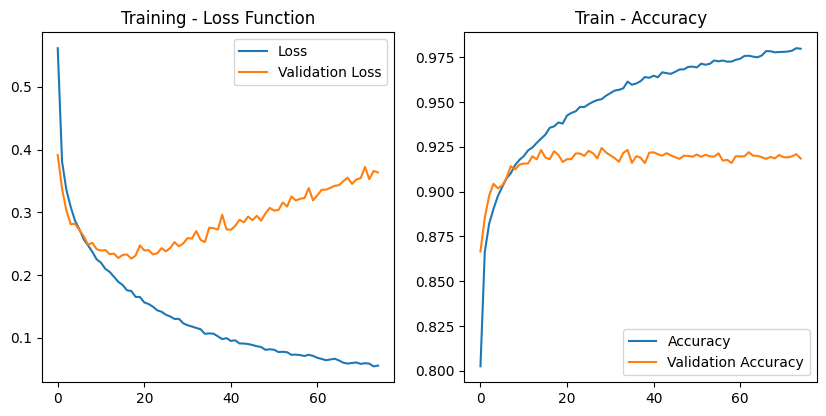

In [ ]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Training - Loss Function')

plt.subplot(2, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Train - Accuracy')

#### Explicação:
- **Perda:** Mostra a evolução da função de perda no conjunto de treino e validação.
- **Acurácia:** Plota a acurácia ao longo das épocas.
- **Visualização:** Auxilia na detecção de overfitting se houver uma grande diferença entre a perda de treino e validação.

In [ ]:
score = cnn_model.evaluate(x_test,y_test,verbose=0)
print('Test Loss : {:.4f}'.format(score[0]))
print('Test Accuracy : {:.4f}'.format(score[1]))

Test Loss : 0.3969
Test Accuracy : 0.9124


#### **Explicação**
- **Avaliação com `evaluate()`:** Calcula a perda (`loss`) e a métrica (`accuracy`) no conjunto de teste.
- **`verbose=0`:** Oculta a barra de progresso durante a avaliação.

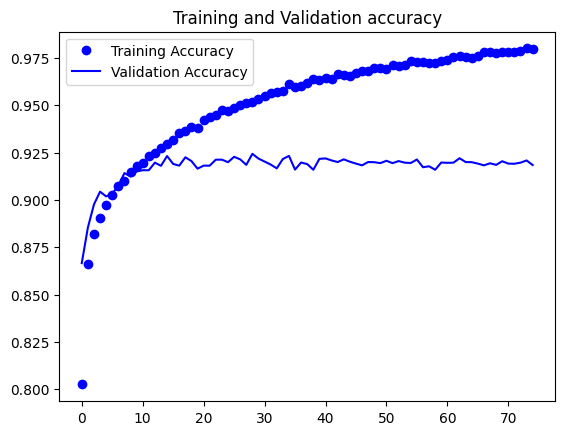

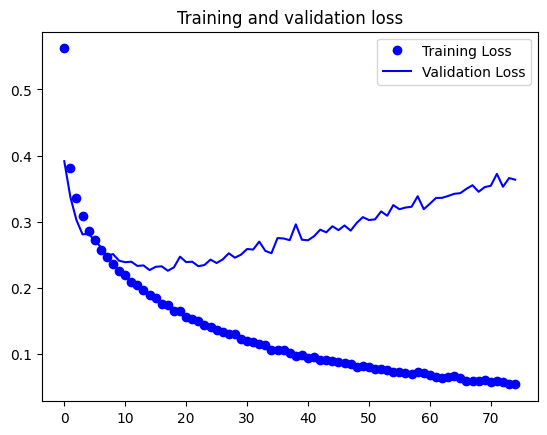

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

#### **Explicação**
- **Gráficos:** Visualiza a evolução da acurácia e perda para os conjuntos de treino e validação ao longo das épocas.
- **Objetivo:** Detectar tendências de overfitting ou underfitting.


In [ ]:
#Get the predictions for the test data
predicted_classes = np.argmax(cnn_model.predict(x_test), axis=-1)
#Get the indices to be plotted
y_true = test_df.iloc[:, 0]
correct = np.nonzero(predicted_classes==y_true)[0]
incorrect = np.nonzero(predicted_classes!=y_true)[0]
from sklearn.metrics import classification_report
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(y_true, predicted_classes, target_names=target_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

     Class 0       0.84      0.88      0.86      1000
     Class 1       0.99      0.98      0.98      1000
     Class 2       0.90      0.83      0.86      1000
     Class 3       0.92      0.91      0.92      1000
     Class 4       0.86      0.87      0.86      1000
     Class 5       0.97      0.98      0.98      1000
     Class 6       0.76      0.76      0.76      1000
     Class 7       0.96      0.96      0.96      1000
     Class 8       0.97      0.98      0.98      1000
     Class 9       0.97      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



#### **Explicação**
- **Predições:** `np.argmax()` pega o índice da classe com a maior probabilidade na saída `softmax`.
- **Métricas:** `classification_report()` fornece precisão, recall e F1-score para cada classe.


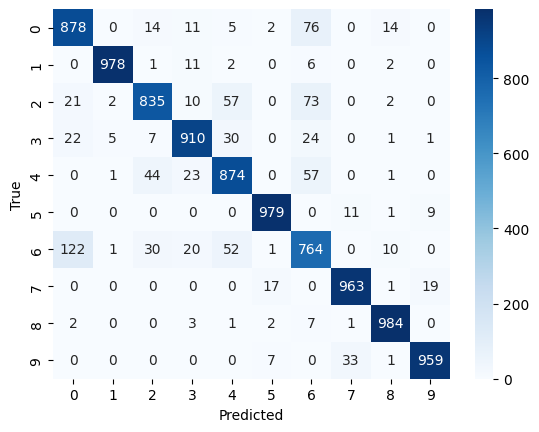

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, predicted_classes)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

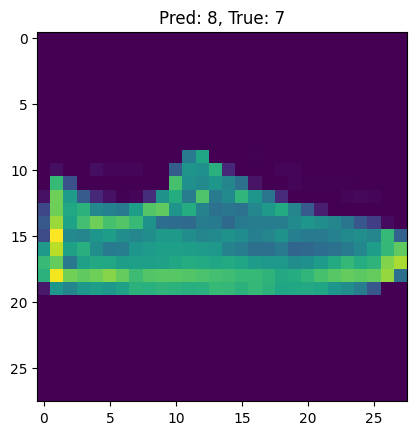

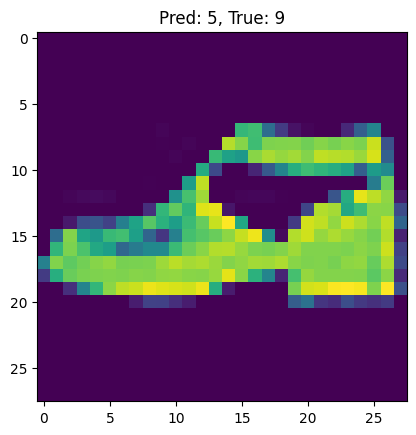

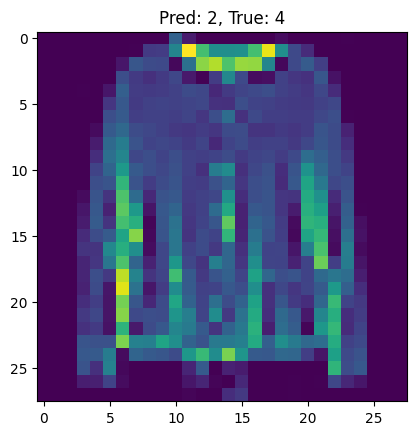

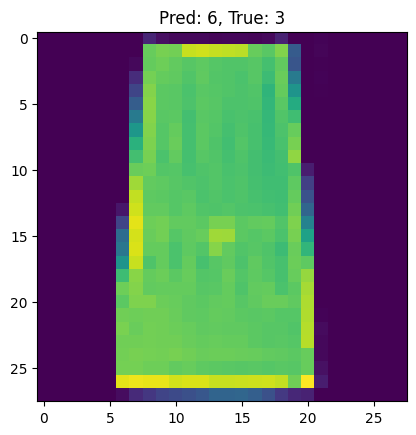

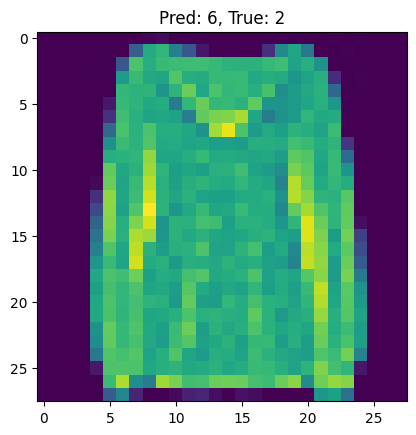

In [ ]:
for i in incorrect[:5]:
       plt.imshow(x_test[i].reshape(28,28))
       plt.title(f"Pred: {predicted_classes[i]}, True: {y_true.iloc[i]}")
       plt.show()

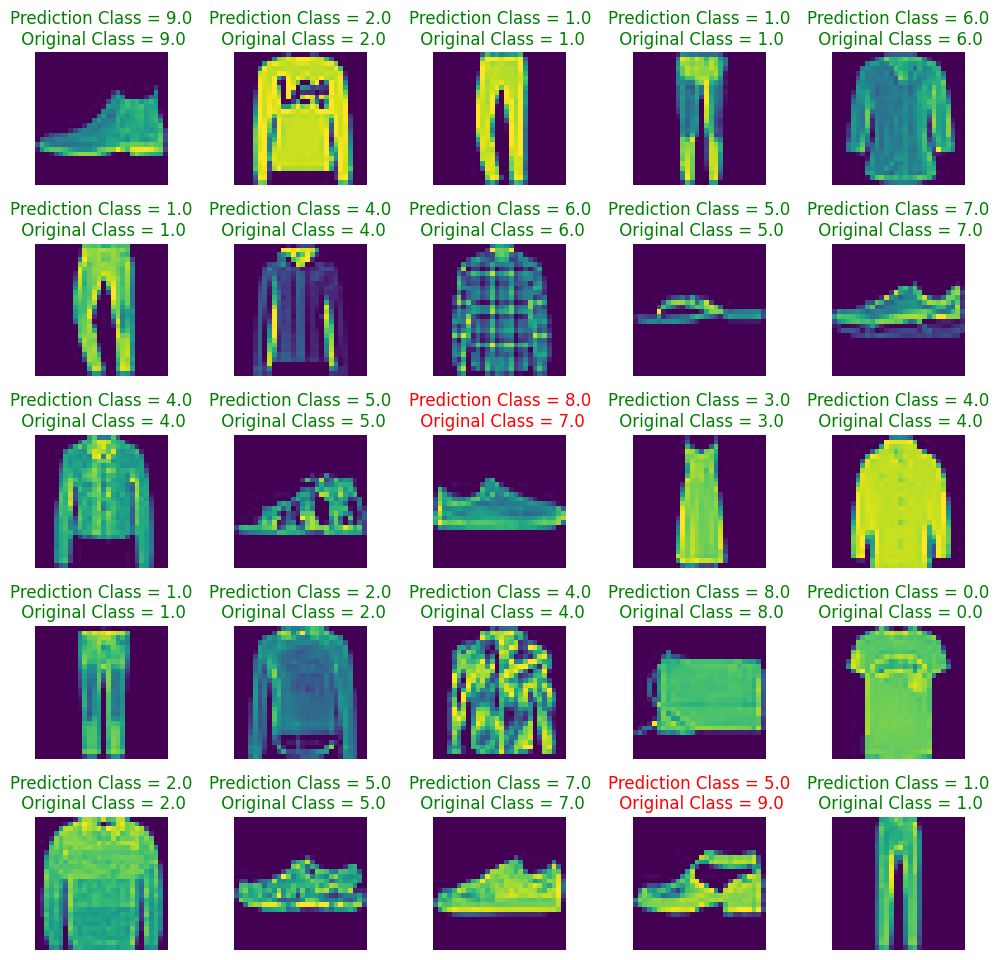

In [ ]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(x_test[i].reshape(28,28))
    color = 'green' if predicted_classes[i] == y_test[i] else 'red'
    axes[i].set_title(f"Predicted: {predicted_classes[i]} | True: {y_test[i]}", color=color)
    axes[i].set_title(f"Prediction Class = {predicted_classes[i]:0.1f}\n Original Class = {y_test[i]:0.1f}")
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

# Alterações possíveis:
* Data augmentation para diminuir o efeito de overfitting do modelo;
* Aumentar a complexidade do modelo;

## Tentando melhorar o modelo!!

In [ ]:
cnn_model = Sequential([
    # Bloco Convolucional 1
    Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=image_shape),
    MaxPooling2D(pool_size=2),

    # Bloco Convolucional 2
    Conv2D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),

    # Bloco Convolucional 3
    Conv2D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),

    Dropout(0.4),  # Aumentar dropout para reduzir overfitting
    Flatten(),

    # Camadas Densas
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

- Camadas convolucionais adicionais capturam padrões espaciais complexos.
- Aumentei o `Dropout` para evitar a dependência do modelo em padrões específicos do conjunto de treinamento.
- **Número crescente de filtros:** Começamos com 32 e aumentamos para 128, permitindo maior capacidade de extração de características.

In [ ]:
cnn_model.compile(loss ='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics =['accuracy'])

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

with tf.device('/GPU:0'):
  history = cnn_model.fit(
      x_train,
      y_train,
      batch_size=128,
      epochs=75,
      verbose=1,
      validation_data=(x_validate,y_validate),
      callbacks=[early_stopping, reduce_lr]
  )

Epoch 1/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.5431 - loss: 1.2282 - val_accuracy: 0.8065 - val_loss: 0.5452 - learning_rate: 0.0010
Epoch 2/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7801 - loss: 0.6061 - val_accuracy: 0.8341 - val_loss: 0.4523 - learning_rate: 0.0010
Epoch 3/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8128 - loss: 0.5145 - val_accuracy: 0.8463 - val_loss: 0.4115 - learning_rate: 0.0010
Epoch 4/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8249 - loss: 0.4766 - val_accuracy: 0.8655 - val_loss: 0.3710 - learning_rate: 0.0010
Epoch 5/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8421 - loss: 0.4357 - val_accuracy: 0.8596 - val_loss: 0.3787 - learning_rate: 0.0010
Epoch 6/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8509 - loss: 0.4091 - val_accuracy: 0.8779 - val_loss: 0.3331 - learning_rate: 0.0010
Epoch 7/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8597 - loss: 0.3816 - 

In [ ]:
score = cnn_model.evaluate(x_test,y_test,verbose=0)
print('Test Loss : {:.4f}'.format(score[0]))
print('Test Accuracy : {:.4f}'.format(score[1]))

Test Loss : 0.2973
Test Accuracy : 0.8986


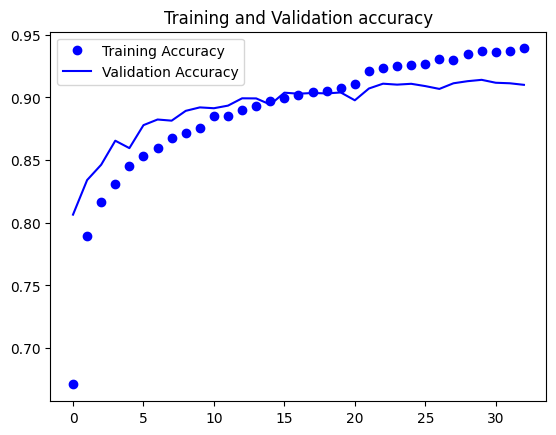

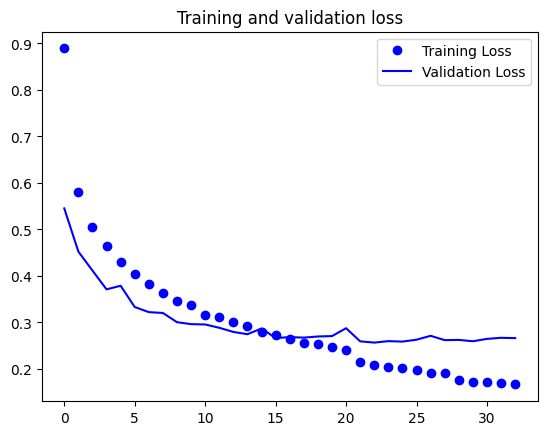

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

     Class 0       0.86      0.85      0.85      1000
     Class 1       0.99      0.98      0.99      1000
     Class 2       0.83      0.85      0.84      1000
     Class 3       0.90      0.90      0.90      1000
     Class 4       0.83      0.85      0.84      1000
     Class 5       0.98      0.97      0.97      1000
     Class 6       0.71      0.69      0.70      1000
     Class 7       0.95      0.96      0.96      1000
     Class 8       0.97      0.98      0.97      1000
     Class 9       0.96      0.97      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



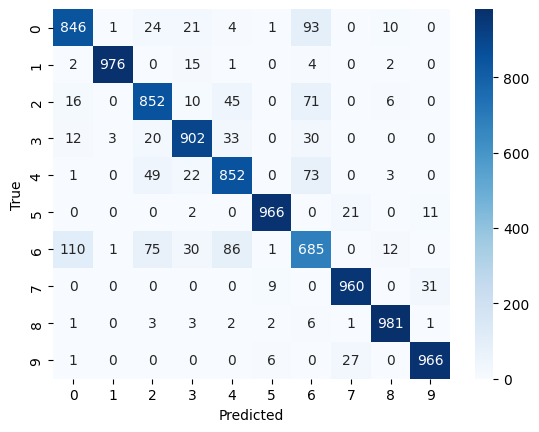

In [ ]:
#Get the predictions for the test data
predicted_classes = np.argmax(cnn_model.predict(x_test), axis=-1)
#Get the indices to be plotted
y_true = test_df.iloc[:, 0]
correct = np.nonzero(predicted_classes==y_true)[0]
incorrect = np.nonzero(predicted_classes!=y_true)[0]
from sklearn.metrics import classification_report
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(y_true, predicted_classes, target_names=target_names))

from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, predicted_classes)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

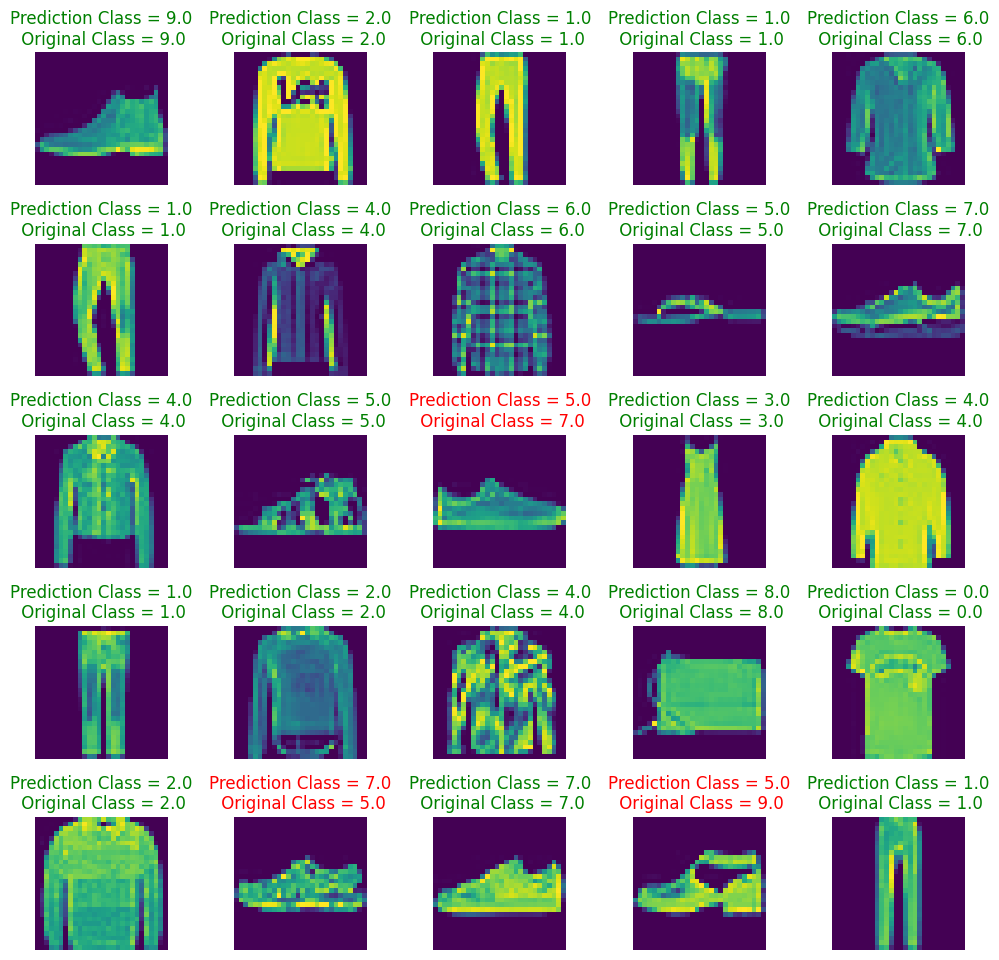

In [ ]:
L = 5
W = 5
fig, axes = plt.subplots(L, W, figsize = (12,12))
axes = axes.ravel()

for i in np.arange(0, L * W):
    axes[i].imshow(x_test[i].reshape(28,28))
    color = 'green' if predicted_classes[i] == y_test[i] else 'red'
    axes[i].set_title(f"Predicted: {predicted_classes[i]} | True: {y_test[i]}", color=color)
    axes[i].set_title(f"Prediction Class = {predicted_classes[i]:0.1f}\n Original Class = {y_test[i]:0.1f}")
    axes[i].axis('off')

plt.subplots_adjust(wspace=0.5)

Ainda é possível melhorar mais aumentando o número de dados....

In [ ]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

cnn_model = Sequential([
    # Data Augmentation
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # Bloco Convolucional 1
    Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=image_shape),
    MaxPooling2D(pool_size=2),

    # Bloco Convolucional 2
    Conv2D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),

    # Bloco Convolucional 3
    Conv2D(filters=128, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),

    Dropout(0.4),  # Aumentar dropout para reduzir overfitting
    Flatten(),

    # Camadas Densas
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

In [ ]:
cnn_model.compile(loss ='sparse_categorical_crossentropy',
                  optimizer=Adam(learning_rate=0.001),
                  metrics =['accuracy'])

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

with tf.device('/GPU:0'):
  history = cnn_model.fit(
      x_train,
      y_train,
      batch_size=128,
      epochs=75,
      verbose=1,
      validation_data=(x_validate,y_validate),
      callbacks=[early_stopping, reduce_lr]
  )

Epoch 1/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.4528 - loss: 1.4759 - val_accuracy: 0.7142 - val_loss: 0.7615 - learning_rate: 0.0010
Epoch 2/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.6920 - loss: 0.8248 - val_accuracy: 0.7415 - val_loss: 0.6751 - learning_rate: 0.0010
Epoch 3/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7249 - loss: 0.7408 - val_accuracy: 0.7802 - val_loss: 0.5890 - learning_rate: 0.0010
Epoch 4/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7427 - loss: 0.6830 - val_accuracy: 0.7949 - val_loss: 0.5517 - learning_rate: 0.0010
Epoch 5/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7562 - loss: 0.6489 - val_accuracy: 0.8123 - val_loss: 0.5140 - learning_rate: 0.0010
Epoch 6/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7700 - loss: 0.6220 - val_accuracy: 0.8150 - val_loss: 0.5063 - learning_rate: 0.0010
Epoch 7/75
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7866 - loss: 0.5794 -

In [ ]:
score = cnn_model.evaluate(x_test,y_test,verbose=0)
print('Test Loss : {:.4f}'.format(score[0]))
print('Test Accuracy : {:.4f}'.format(score[1]))

Test Loss : 0.3605
Test Accuracy : 0.8681


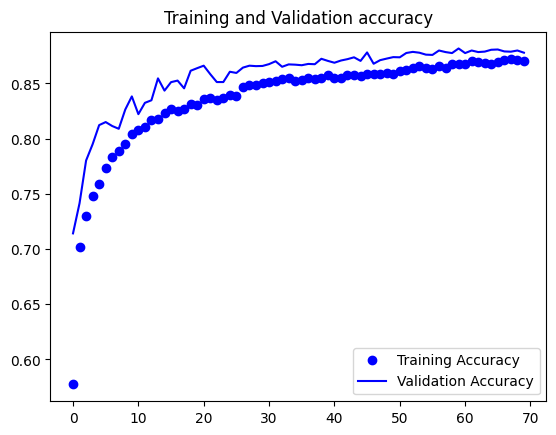

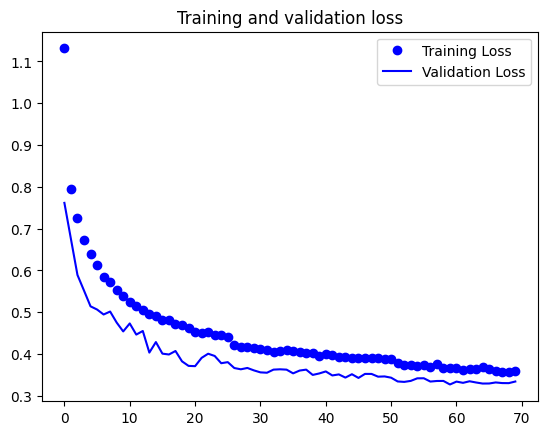

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()


In [ ]:
#Get the predictions for the test data
predicted_classes = np.argmax(cnn_model.predict(x_test), axis=-1)
#Get the indices to be plotted
y_true = test_df.iloc[:, 0]
correct = np.nonzero(predicted_classes==y_true)[0]
incorrect = np.nonzero(predicted_classes!=y_true)[0]
from sklearn.metrics import classification_report
target_names = ["Class {}".format(i) for i in range(num_classes)]
print(classification_report(y_true, predicted_classes, target_names=target_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

     Class 0       0.84      0.83      0.83      1000
     Class 1       0.98      0.97      0.98      1000
     Class 2       0.78      0.85      0.82      1000
     Class 3       0.88      0.87      0.87      1000
     Class 4       0.81      0.76      0.79      1000
     Class 5       0.93      0.96      0.95      1000
     Class 6       0.63      0.62      0.62      1000
     Class 7       0.92      0.91      0.92      1000
     Class 8       0.97      0.96      0.96      1000
     Class 9       0.95      0.93      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



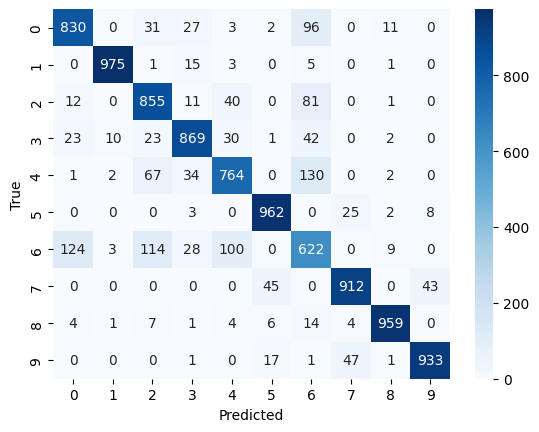

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_true, predicted_classes)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

## TensorFlow Tutorial 1

In [ ]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

print("Num GPUs Disponível: ", len(tf.config.experimental.list_physical_devices('GPU')))

Num GPUs Disponível:  1


**Explicação:**  
- Importa o TensorFlow e suas subbibliotecas (`datasets`, `layers`, `models`).
- `matplotlib.pyplot` é usado para visualizar imagens do dataset.

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

**Explicação:**  
- Carrega o dataset **CIFAR-10**, que contém **60.000 imagens de 32x32 pixels em 10 classes** (50.000 para treino e 10.000 para teste).
- Normaliza os pixels para ficarem entre **0 e 1**, melhorando a estabilidade do treinamento da rede neural.

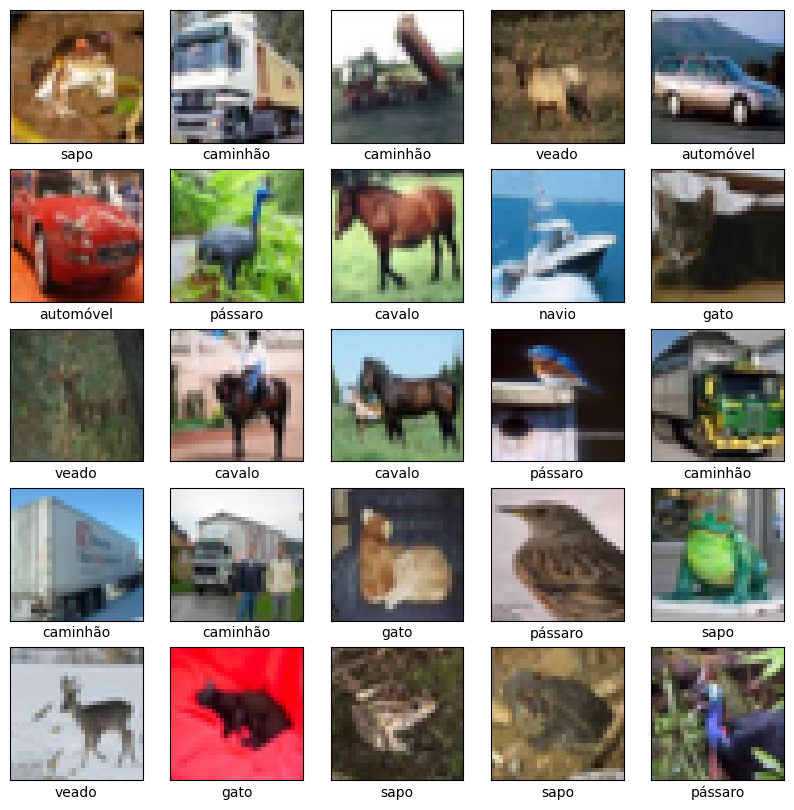

In [ ]:
class_names = ['avião', 'automóvel', 'pássaro', 'gato', 'veado',
               'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # The CIFAR labels happen to be arrays,
    # which is why you need the extra index
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

**Explicação:**  
- Exibe 25 imagens do conjunto de treinamento com seus respectivos rótulos.  
- Importante para verificar se os dados foram carregados corretamente.

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,320 (220.00 KB)

 Trainable params: 56,320 (220.00 KB)

 Non-trainable params: 0 (0.00 B)

**Explicação:**  
- **3 camadas convolucionais** (`Conv2D`) com filtros de **32, 64, e 64**, detectam padrões na imagem.  
- Cada convolução tem **kernel de (3x3)** e usa **ReLU** para ativação, ajudando a capturar bordas e texturas.  
- **`MaxPooling2D(2,2)`** reduz a dimensionalidade e previne overfitting.  
- O **`summary()`** exibe a arquitetura do modelo.  

**Sugestão:**  
✅ Adicionar **camadas de Batch Normalization** para melhorar a estabilidade do treinamento.  
✅ Aumentar **número de filtros** e **profundidade da rede** para capturar mais características da imagem.  

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 4, 4, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │          65,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

**Explicação:**  
- `Flatten()` transforma os mapas de características 2D em um vetor 1D.  
- `Dense(64, activation='relu')` adiciona uma camada oculta totalmente conectada.  
- `Dense(10)` gera a saída de **10 classes** (não usa softmax porque `SparseCategoricalCrossentropy(from_logits=True)` já incorpora isso).  

**Sugestão:**  
✅ **Aumentar o número de neurônios** na camada densa (128 ou 256).  
✅ Adicionar **Dropout (0.3 - 0.5)** para evitar overfitting.  

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)

with tf.device('/GPU:0'):
  history = model.fit(train_images, train_labels, epochs=50,
                      validation_data=(test_images, test_labels),
                      callbacks=[early_stopping, reduce_lr])

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.3576 - loss: 1.7418 - val_accuracy: 0.5636 - val_loss: 1.2186 - learning_rate: 0.0010
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.5850 - loss: 1.1681 - val_accuracy: 0.6295 - val_loss: 1.0535 - learning_rate: 0.0010
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6464 - loss: 1.0051 - val_accuracy: 0.6620 - val_loss: 0.9712 - learning_rate: 0.0010
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6864 - loss: 0.8867 - val_accuracy: 0.6764 - val_loss: 0.9373 - learning_rate: 0.0010
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7158 - loss: 0.8203 - val_accuracy: 0.6977 - val_loss: 0.8683 - learning_rate: 0.0010
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7397 - loss: 0.7401 - val_accuracy: 0.7048 - val_loss: 0.8607 - learning_rate: 0.0010
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7602 

- **`EarlyStopping`** e **`ReduceLROnPlateau`** são **callbacks** do Keras.  
- **Callbacks** são funções que monitoram o treinamento e ajustam automaticamente parâmetros para melhorar o desempenho.
- **`optimizer='adam'`** → Usa o **Adam**, um otimizador adaptativo eficiente.  
- **`loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)`** →  
  - Como a saída do modelo não tem `softmax`, usamos `from_logits=True` para calcular a entropia cruzada corretamente.  
- **`metrics=['accuracy']`** → Mede a acurácia durante o treinamento.

```python
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
```
- **Objetivo:** Evitar **overfitting** interrompendo o treinamento quando o modelo não melhora.  
- **`monitor='val_loss'`** → Monitora a **perda (loss) na validação**.  
- **`patience=5`** → Espera **5 épocas** sem melhora antes de parar.  
- **`restore_best_weights=True`** → Retorna ao **melhor estado do modelo**, antes da piora.

```python
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
```
- **Objetivo:** Ajustar a taxa de aprendizado quando o modelo "empaca" na validação.  
- **`monitor='val_loss'`** → Monitora a **perda na validação**.  
- **`factor=0.5`** → Reduz a taxa de aprendizado para **50% do valor atual**.  
- **`patience=3`** → Espera **3 épocas** sem melhora antes de reduzir a taxa.  
- **`min_lr=0.00001`** → Define um limite mínimo para evitar taxas **muito pequenas**.

313/313 - 1s - 2ms/step - accuracy: 0.7087 - loss: 0.8518


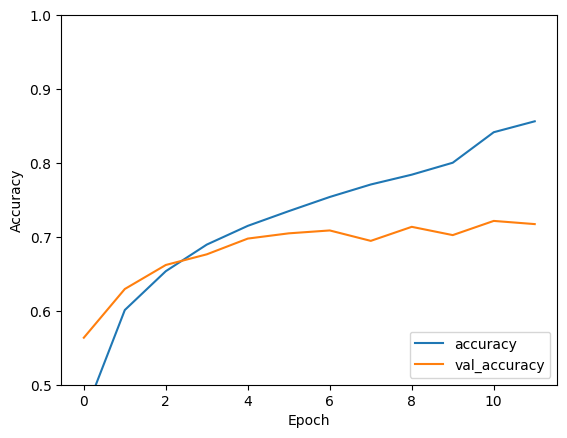

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

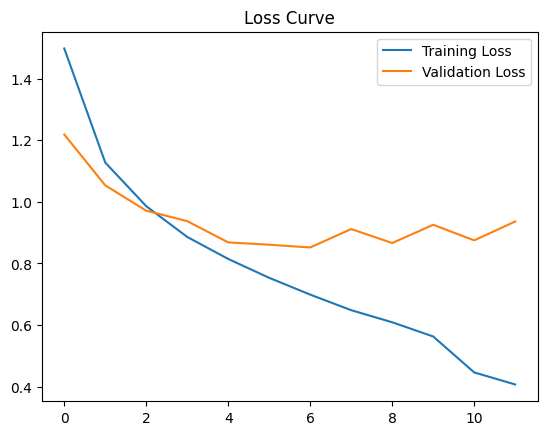

In [ ]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

**Explicação:**  
- Plota a **acurácia de treino e validação** ao longo das épocas.  
- Avalia o modelo no conjunto de **teste** e imprime a **acurácia final**.  

In [ ]:
print(test_acc)

0.7087000012397766


## Tentando melhorar o modelo TensorFlow

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

from tensorflow.keras.layers import Dense, Flatten, Conv2D
from tensorflow.keras import datasets, Model, layers

TensorFlow version: 2.18.0


Aqui, importamos o TensorFlow e imprimimos sua versão para garantir compatibilidade. Também importamos camadas essenciais para a construção de modelos:  
- `Conv2D`: Camada convolucional para detectar padrões nas imagens.  
- `Flatten`: Achata a saída da convolução para um vetor unidimensional.  
- `Dense`: Camada totalmente conectada (FC, Fully Connected).  
- `Model`: Classe base do Keras para definir modelos personalizados.

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)).shuffle(10000).batch(64)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(64)

train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

**Explicação:**  
- O CIFAR-10 é carregado. Ele contém **60.000 imagens (50.000 treino, 10.000 teste)** de **10 classes**.  
- As imagens são normalizadas dividindo por `255.0`, reduzindo os valores de 0-255 para 0-1. Isso acelera o aprendizado e melhora a estabilidade da rede.  
- `tf.data.Dataset.from_tensor_slices` transforma os dados em um formato eficiente para treinamento.  
  - `shuffle(10000)`: Embaralha os dados (evita overfitting ao treinar sempre na mesma ordem).  
  - `batch(64)`: Divide os dados em lotes de 64 imagens para cada iteração de treino.  

In [ ]:
class MyModel(Model):
  def __init__(self):
    super().__init__()
    self.conv1 = Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3))
    self.conv2 = Conv2D(64, (3, 3), activation='relu')
    self.pool = layers.MaxPooling2D((2, 2))
    self.flatten = Flatten()
    self.d1 = Dense(128, activation='relu')
    self.dropout = layers.Dropout(0.3)
    self.d2 = Dense(10)

  def call(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.pool(x)
    x = self.flatten(x)
    x = self.d1(x)
    x = self.dropout(x)
    return self.d2(x)

# Create an instance of the model
model = MyModel()

**Explicação:**  
- Criamos uma classe `MyModel` baseada na classe `Model` do Keras, permitindo maior flexibilidade.  
- A estrutura é:
  1. **Camada Convolucional (32 filtros, 3x3, ReLU)**: Detecta padrões na imagem.  
  2. **Flatten**: Converte a saída da convolução em um vetor 1D.  
  3. **Dense (128 neurônios, ReLU)**: Aprendizado de alto nível.  
  4. **Dense (10 neurônios, sem ativação)**: Saída para 10 classes.

In [ ]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

In [ ]:
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')

test_loss = tf.keras.metrics.Mean(name='test_loss')
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='test_accuracy')

In [ ]:
@tf.function
def train_step(images, labels):
  with tf.GradientTape() as tape:
    # training=True is only needed if there are layers with different
    # behavior during training versus inference (e.g. Dropout).
    predictions = model(images, training=True)
    loss = loss_object(labels, predictions)
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))

  train_loss(loss)
  train_accuracy(labels, predictions)

**Explicação:**  
- `GradientTape()`: Grava as operações para calcular os gradientes automaticamente.  
- `train_loss(loss)`: Armazena a loss para monitoramento.  
- `train_accuracy(labels, predictions)`: Calcula a acurácia.

In [ ]:
@tf.function
def test_step(images, labels):
  # training=False is only needed if there are layers with different
  # behavior during training versus inference (e.g. Dropout).
  predictions = model(images, training=False)
  t_loss = loss_object(labels, predictions)

  test_loss(t_loss)
  test_accuracy(labels, predictions)

**Explicação:**  
- `training=False`: Desativa dropout e batch normalization durante a inferência.  
- Mede `test_loss` e `test_accuracy`.

In [ ]:
EPOCHS = 20

train_loss_history = []
test_loss_history = []
train_acc_history = []
test_acc_history = []

with tf.device('/GPU:0'):
  for epoch in range(EPOCHS):
    # Reset the metrics at the start of the next epoch
    train_loss.reset_state()
    train_accuracy.reset_state()
    test_loss.reset_state()
    test_accuracy.reset_state()

    for images, labels in train_ds:
      train_step(images, labels)

    for test_images, test_labels in test_ds:
      test_step(test_images, test_labels)

    # Save history
    train_loss_history.append(train_loss.result().numpy())
    test_loss_history.append(test_loss.result().numpy())
    train_acc_history.append(train_accuracy.result().numpy())
    test_acc_history.append(test_accuracy.result().numpy())

    print(
      f'Epoch {epoch + 1}, '
      f'Loss: {train_loss.result():0.2f}, '
      f'Accuracy: {train_accuracy.result() * 100:0.2f}, '
      f'Test Loss: {test_loss.result():0.2f}, '
      f'Test Accuracy: {test_accuracy.result() * 100:0.2f}'
    )

Epoch 1, Loss: 1.43, Accuracy: 49.09, Test Loss: 1.16, Test Accuracy: 58.66
Epoch 2, Loss: 1.04, Accuracy: 63.48, Test Loss: 0.99, Test Accuracy: 65.77
Epoch 3, Loss: 0.89, Accuracy: 69.23, Test Loss: 0.98, Test Accuracy: 66.64
Epoch 4, Loss: 0.78, Accuracy: 73.08, Test Loss: 0.96, Test Accuracy: 67.36
Epoch 5, Loss: 0.68, Accuracy: 76.42, Test Loss: 0.97, Test Accuracy: 67.32
Epoch 6, Loss: 0.59, Accuracy: 79.63, Test Loss: 0.97, Test Accuracy: 67.97
Epoch 7, Loss: 0.50, Accuracy: 82.71, Test Loss: 1.01, Test Accuracy: 68.20
Epoch 8, Loss: 0.41, Accuracy: 85.71, Test Loss: 1.10, Test Accuracy: 68.03
Epoch 9, Loss: 0.34, Accuracy: 88.48, Test Loss: 1.24, Test Accuracy: 67.37
Epoch 10, Loss: 0.27, Accuracy: 90.79, Test Loss: 1.38, Test Accuracy: 66.89
Epoch 11, Loss: 0.20, Accuracy: 93.19, Test Loss: 1.49, Test Accuracy: 67.12
Epoch 12, Loss: 0.15, Accuracy: 94.71, Test Loss: 1.63, Test Accuracy: 66.82
Epoch 13, Loss: 0.12, Accuracy: 95.78, Test Loss: 1.85, Test Accuracy: 66.52
Epoch 14

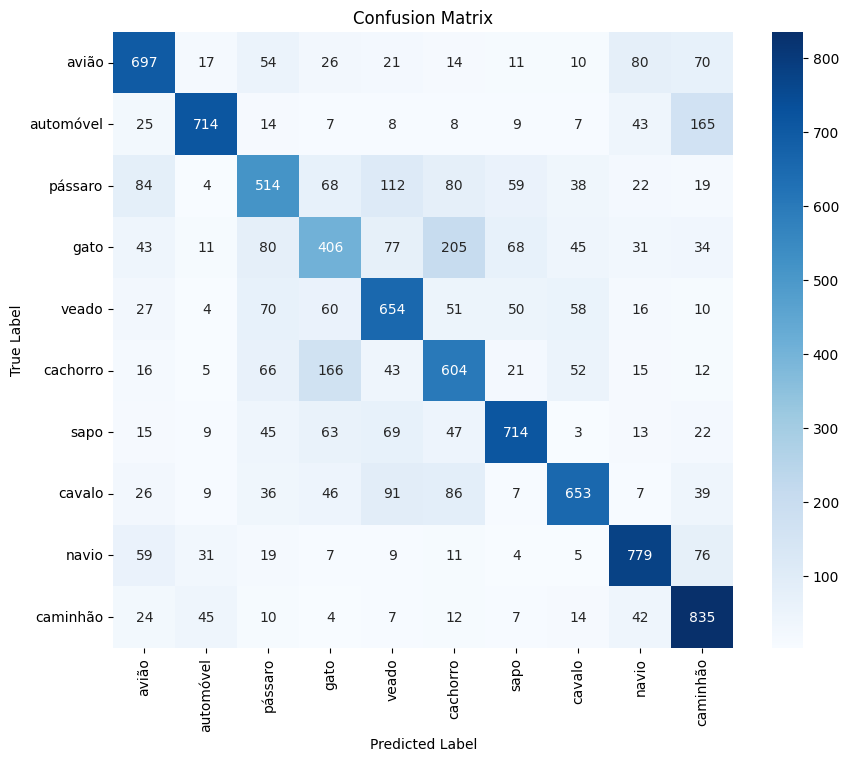

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
class_names = ['avião', 'automóvel', 'pássaro', 'gato', 'veado',
               'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']
# Obter previsões no conjunto de teste
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model(images, training=False)  # Obter previsões
    y_pred.extend(np.argmax(preds.numpy(), axis=1))
    y_true.extend(labels.numpy().flatten())  # Flatten pois os rótulos têm shape (batch_size, 1)

# Criar matriz de confusão
cm = confusion_matrix(y_true, y_pred)

# Plotar matriz de confusão
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Outro modelo

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Convert target variable to categorical (one-hot encoding)
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau

In [ ]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

# Convert target variable to categorical (one-hot encoding)
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

x_train = x_train.reshape(-1, 32, 32, 3)
x_test = x_test.reshape(-1, 32, 32, 3)

print(f"Train Data Shape: {x_train.shape}, Train Labels: {y_train.shape}")
print(f"Test Data Shape: {x_test.shape}, Test Labels: {y_test.shape}")

Train Data Shape: (50000, 32, 32, 3), Train Labels: (50000, 10)
Test Data Shape: (10000, 32, 32, 3), Test Labels: (10000, 10)


In [ ]:
model = Sequential()

# Camada 1
model.add(Conv2D(filters=32, kernel_size=(5,5), padding='Same', activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.3))

# Camada 2
model.add(Conv2D(filters=64, kernel_size=(3,3), padding='Same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.4))

# Fully Connected
model.add(Flatten())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))

In [ ]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = Adam(learning_rate=lr_schedule)

In [ ]:
# Compile the model
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

In [ ]:
epochs = 10  # for better result increase the epochs
batch_size = 250

In [ ]:
# Fit the model
with tf.device('/GPU:0'):
    history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.2838 - loss: 1.9370 - val_accuracy: 0.5030 - val_loss: 1.4350
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.4765 - loss: 1.4646 - val_accuracy: 0.5333 - val_loss: 1.3325
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5268 - loss: 1.3310 - val_accuracy: 0.5940 - val_loss: 1.1540
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5669 - loss: 1.2218 - val_accuracy: 0.6238 - val_loss: 1.0933
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5880 - loss: 1.1576 - val_accuracy: 0.6380 - val_loss: 1.0581
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6016 - loss: 1.1230 - val_accuracy: 0.6585 - val_loss: 1.0013
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6205 - loss: 1.0720 - val_accuracy: 0.6661 - val_loss: 0.9556
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6364 - loss: 1.0346 - val_accu

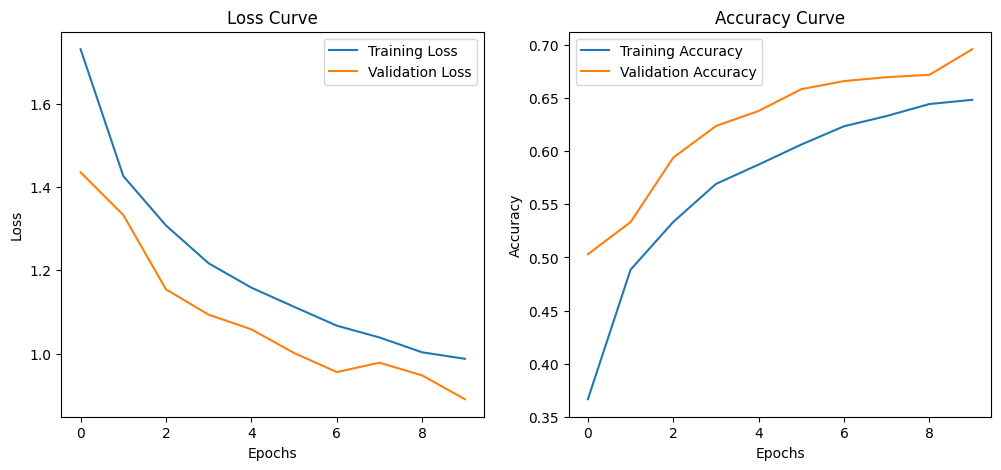

In [ ]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


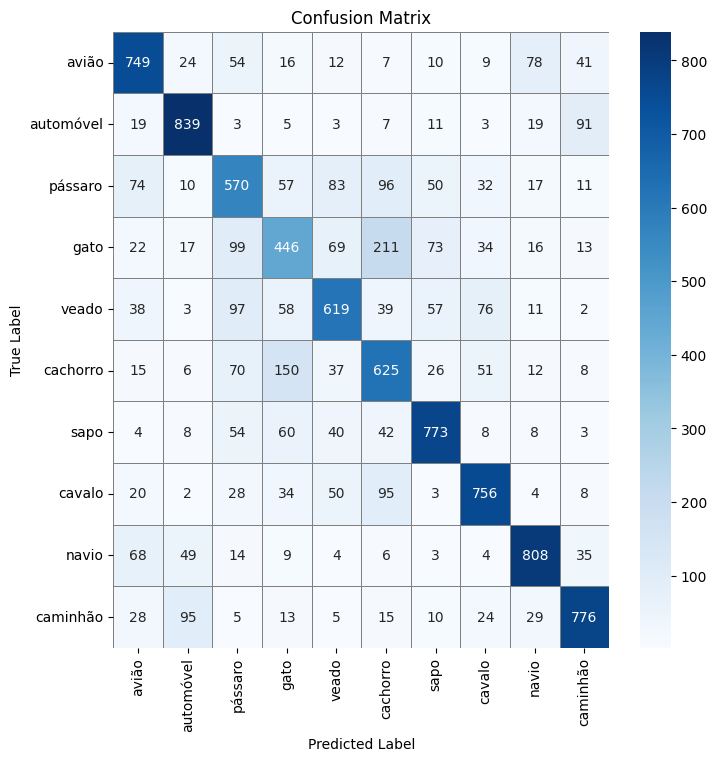

In [ ]:
class_names = ['avião', 'automóvel', 'pássaro', 'gato', 'veado',
               'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']
Y_pred = model.predict(x_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(y_test, axis=1)
confusion_mtx = confusion_matrix(Y_true, Y_pred_classes)

plt.figure(figsize=(8, 8))
sns.heatmap(confusion_mtx, annot=True, linewidths=0.5, cmap="Blues", linecolor="gray", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# CNN para análise de expressoes faciais

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import warnings
from tensorflow.keras.models import Sequential, Model
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adamax
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Input
from keras.regularizers import l1, l2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import plotly.express as px

warnings.simplefilter("ignore")

In [ ]:
data = pd.read_csv("fer2013.csv", on_bad_lines='skip')
data.shape

(35887, 3)

In [ ]:
data.isnull().sum()

,0
emotion,0
pixels,0
Usage,0


In [ ]:
data.dropna(inplace=True)

- Lê o dataset **FER2013** (`fer2013.csv`), que contém imagens de rostos humanos e suas expressões faciais associadas.  
- `data.shape` imprime o tamanho do dataset (número de linhas e colunas).  
- `data.isnull().sum()` verifica se há valores nulos.  
- `data.dropna(inplace=True)` remove qualquer linha com valores ausentes.  

In [ ]:
data.tail()

,emotion,pixels,Usage
35882,6,50 36 17 22 23 29 33 39 34 37 37 37 39 43 48 5...,PrivateTest
35883,3,178 174 172 173 181 188 191 194 196 199 200 20...,PrivateTest
35884,0,17 17 16 23 28 22 19 17 25 26 20 24 31 19 27 9...,PrivateTest
35885,3,30 28 28 29 31 30 42 68 79 81 77 67 67 71 63 6...,PrivateTest
35886,2,19 13 14 12 13 16 21 33 50 57 71 84 97 108 122...,PrivateTest


In [ ]:
data.shape

(35887, 3)

In [ ]:
CLASS_LABELS = ['Raiva', 'Nojo', 'Medo', 'Feliz', 'Neutro', 'Tristeza', "Surpresa"]
emotion_counts = data['emotion'].value_counts()
fig = px.bar(x=CLASS_LABELS, y=emotion_counts, color=emotion_counts, color_continuous_scale="Emrld")
# fig = px.bar(x = CLASS_LABELS,
#              y = [list(data['emotion']).count(i) for i in np.unique(data['emotion'])] ,
#              color = np.unique(data['emotion']) ,
#              color_continuous_scale="Emrld")
fig.update_xaxes(title="Emotions")
fig.update_yaxes(title = "Number of Images")
fig.update_layout(showlegend = True,
    title = {
        'text': 'Train Data Distribution ',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})
fig.show()

- Define os rótulos das emoções.  
- Cria um **gráfico de barras interativo** com o `plotly.express` para mostrar a distribuição das classes no dataset.  
- Cada emoção é representada por uma cor diferente.  

In [ ]:
data = data.sample(frac=1)

In [ ]:
labels = to_categorical(data[['emotion']], num_classes=7)

In [ ]:
train_pixels = data["pixels"].astype(str).str.split(" ").tolist()
# train_pixels is now a list of NumPy arrays, each representing an image
train_pixels = np.array(train_pixels, dtype=int)
# train_pixels is now a NumPy array of NumPy arrays, suitable for further processing

- **`data.sample(frac=1)`** → embaralha os dados para evitar viés na ordem das amostras.  
- **`to_categorical(data[['emotion']], num_classes=7)`** → converte os rótulos em **one-hot encoding**.  
- **Converte os pixels de string para uma matriz NumPy** para facilitar a manipulação.  

In [ ]:
pixels = train_pixels.reshape((35887*2304,1))

In [ ]:
scaler = MinMaxScaler()
pixels = pixels.reshape(-1, 1)  # Achata a matriz para normalização
pixels = scaler.fit_transform(pixels)
pixels = pixels.reshape(-1, 48, 48, 1)  # Reshape final

- **Normaliza os pixels** com `MinMaxScaler()` para melhorar a performance do modelo.  
- **Reorganiza os dados** para o formato correto (`48x48` pixels em escala de cinza).  

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(pixels, labels, test_size=0.1, shuffle=True, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, shuffle=True, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(29068, 48, 48, 1)
(3589, 48, 48, 1)
(3230, 48, 48, 1)


- Divide os dados em **treino (80%), validação (10%) e teste (10%)**.  

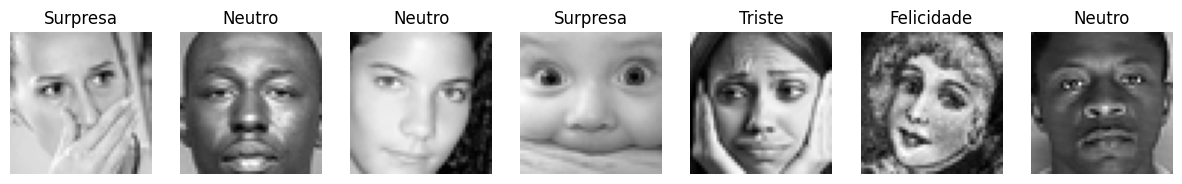

In [ ]:
plt.figure(figsize=(15,23))
label_dict = {0 : 'Bravo', 1 : 'Nojo', 2 : 'Medo', 3 : 'Felicidade', 4 : 'Triste', 5 : 'Surpresa', 6 : 'Neutro'}
i = 1
for i in range (7):
    img = np.squeeze(X_train[i])
    plt.subplot(1,7,i+1)
    plt.imshow(img, cmap='gray')
    index = np.argmax(y_train[i])
    plt.title(label_dict[index])
    plt.axis('off')
    i += 1
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(  width_shift_range = 0.1,
                               height_shift_range = 0.1,
                               horizontal_flip = True,
                               zoom_range = 0.2)
valgen = ImageDataGenerator(   width_shift_range = 0.1,
                               height_shift_range = 0.1,
                               horizontal_flip = True,
                               zoom_range = 0.2)

datagen.fit(X_train)
valgen.fit(X_val)

train_generator = datagen.flow(X_train, y_train, batch_size=64)
val_generator = datagen.flow(X_val, y_val, batch_size=64)

### **Explicação**
- O `ImageDataGenerator` cria geradores para realizar **data augmentation** (aumento de dados), essencial para melhorar o desempenho do modelo em um conjunto de dados limitado, especialmente em tarefas de classificação de imagens.
- **`flow()`** cria um gerador que fornece os dados em mini-lotes (batch) para treinamento e validação.

In [ ]:
def cnn_model():

  model= tf.keras.models.Sequential()
  model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(48, 48,1)))
  model.add(Conv2D(64,(3,3), padding='same', activation='relu' ))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(128,(5,5), padding='same', activation='relu'))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(512,(3,3), padding='same', activation='relu', kernel_regularizer=l2(0.01)))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(512,(3,3), padding='same', activation='relu', kernel_regularizer=l2(0.01)))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Conv2D(512,(3,3), padding='same', activation='relu', kernel_regularizer=l2(0.01)))
  model.add(BatchNormalization())
  model.add(MaxPool2D(pool_size=(2, 2)))
  model.add(Dropout(0.25))

  model.add(Flatten())
  model.add(Dense(256,activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.25))

  model.add(Dense(512,activation = 'relu'))
  model.add(BatchNormalization())
  model.add(Dropout(0.25))

  model.add(Dense(7, activation='softmax'))
  model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])
  return model

### **Explicação**
- **`Sequential()`** define um modelo linear, onde cada camada é adicionada uma após a outra.
- **Camadas de convolução (`Conv2D`)** são usadas para extração de características da imagem.
- **BatchNormalization()** ajuda na estabilidade do treinamento, normalizando a entrada de cada camada.
- **MaxPool2D()** reduz a dimensionalidade das imagens, mantendo as informações mais relevantes.
- **Dropout()** é uma técnica de regularização, prevenindo overfitting, desativando aleatoriamente neurônios durante o treinamento.
- **`Dense()`** define camadas totalmente conectadas, com a última camada sendo uma **softmax** para classificar em 7 classes (emoções).

In [ ]:
model = cnn_model()

In [ ]:
model.compile(
    optimizer = Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

### **Explicação**
- Chama a função `cnn_model()` para criar o modelo.
- Compila o modelo utilizando **Adam** como otimizador com uma taxa de aprendizado de `0.0001`, **categorical_crossentropy** para múltiplas classes e **accuracy** como métrica de desempenho.

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 12, 12, 512)         │         590,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 12, 12, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 6, 6, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 3, 3, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 3, 3, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │              

 Total params: 5,810,183 (22.16 MB)

 Trainable params: 5,805,191 (22.15 MB)

 Non-trainable params: 4,992 (19.50 KB)

In [ ]:
checkpointer = [EarlyStopping(monitor = 'val_accuracy', verbose = 1,
                              restore_best_weights=True,mode="max",patience = 5),
                ModelCheckpoint('best_model.keras',monitor="val_accuracy",verbose=1,
                                save_best_only=True,mode="max")]

### **Explicação**
- **`EarlyStopping()`** interrompe o treinamento se não houver melhoria na métrica `val_accuracy` por um número especificado de épocas (aqui, `patience=5`).
- **`ModelCheckpoint()`** salva o modelo com o melhor desempenho de validação.

In [ ]:
with tf.device('/GPU:0'):
  history = model.fit(train_generator,
                      epochs=30,
                      batch_size=64,
                      verbose=1,
                      callbacks=[checkpointer],
                      validation_data=val_generator)

Epoch 1/30
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1726 - loss: 14.5712
Epoch 1: val_accuracy improved from -inf to 0.26625, saving model to best_model.keras
455/455 ━━━━━━━━━━━━━━━━━━━━ 53s 71ms/step - accuracy: 0.1726 - loss: 14.5690 - val_accuracy: 0.2663 - val_loss: 12.8849
Epoch 2/30
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2065 - loss: 12.6563
Epoch 2: val_accuracy did not improve from 0.26625
455/455 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.2065 - loss: 12.6542 - val_accuracy: 0.2594 - val_loss: 10.9346
Epoch 3/30
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2152 - loss: 10.6522
Epoch 3: val_accuracy did not improve from 0.26625
455/455 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.2152 - loss: 10.6500 - val_accuracy: 0.2567 - val_loss: 8.9882
Epoch 4/30
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2259 - loss: 8.6699
Epoch 4: val_accuracy did not improve from 0.26625
455/455 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - acc

- **`model.fit()`** treina o modelo com os geradores de dados para treinamento e validação. O modelo é treinado por 30 épocas.
- Utiliza o **early stopping** e **checkpointing** para garantir a melhor performance e evitar overfitting.

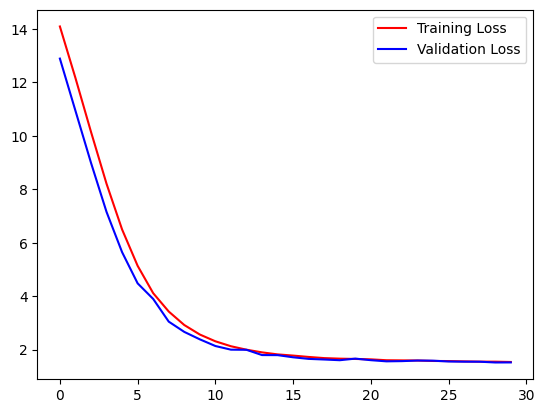

In [ ]:
plt.plot(history.history["loss"],'r', label="Training Loss")
plt.plot(history.history["val_loss"],'b', label="Validation Loss")
plt.legend()

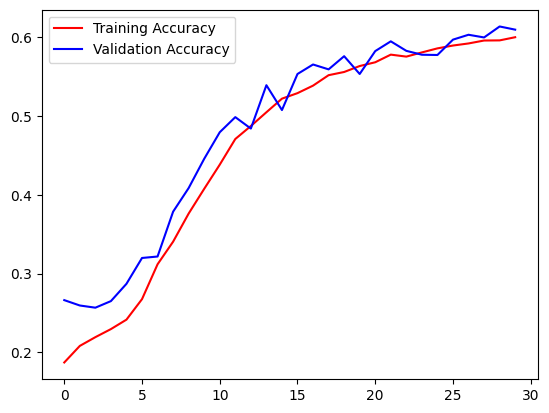

In [ ]:
plt.plot(history.history["accuracy"],'r',label="Training Accuracy")
plt.plot(history.history["val_accuracy"],'b',label="Validation Accuracy")
plt.legend()

### **Explicação**
- Plota as curvas de **loss** e **accuracy** para os dados de treinamento e validação, permitindo a análise do desempenho do modelo.

In [ ]:
loss = model.evaluate(X_test,y_test)
print("Test Acc: " + str(loss[1]))

113/113 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5980 - loss: 1.5109
Test Acc: 0.6129841208457947


In [ ]:
preds = model.predict(X_test)
y_pred = np.argmax(preds , axis = 1 )

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step


### **Explicação**
- **`evaluate()`** avalia o modelo nos dados de teste, retornando o loss e a acurácia.
- **`predict()`** gera as predições para o conjunto de teste, convertendo as probabilidades para as classes com `np.argmax()`.

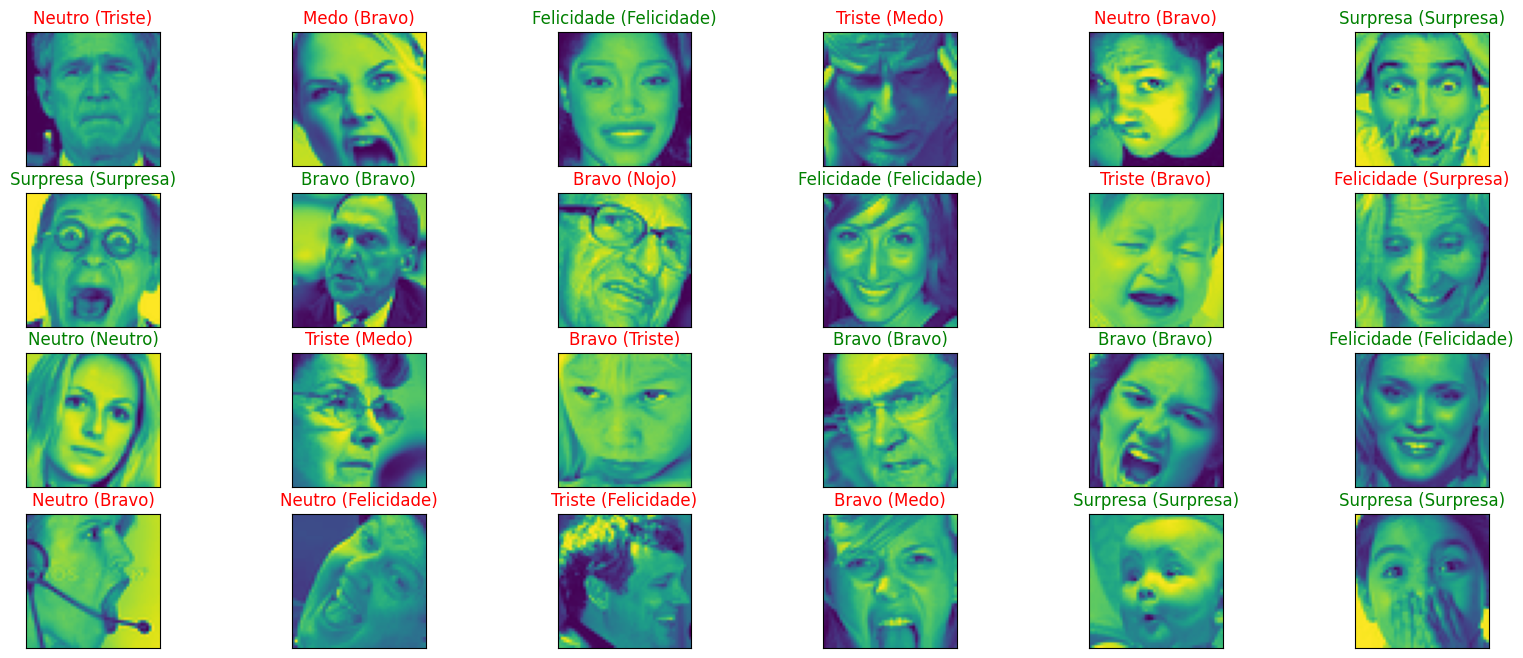

In [ ]:
label_dict = {0 : 'Bravo', 1 : 'Nojo', 2 : 'Medo', 3 : 'Felicidade', 4 : 'Triste', 5 : 'Surpresa', 6 : 'Neutro'}

figure = plt.figure(figsize=(20, 8))
for i, index in enumerate(np.random.choice(X_test.shape[0], size=24, replace=False)):
    ax = figure.add_subplot(4, 6, i + 1, xticks=[], yticks=[])
    ax.imshow(np.squeeze(X_test[index]))
    predict_index = label_dict[(y_pred[index])]
    true_index = label_dict[np.argmax(y_test,axis=1)[index]]

    ax.set_title("{} ({})".format((predict_index),
                                  (true_index)),
                                  color=("green" if predict_index == true_index else "red"))

### **Explicação**
- Exibe imagens aleatórias do conjunto de teste, mostrando as predições feitas pelo modelo e comparando-as com os rótulos verdadeiros.

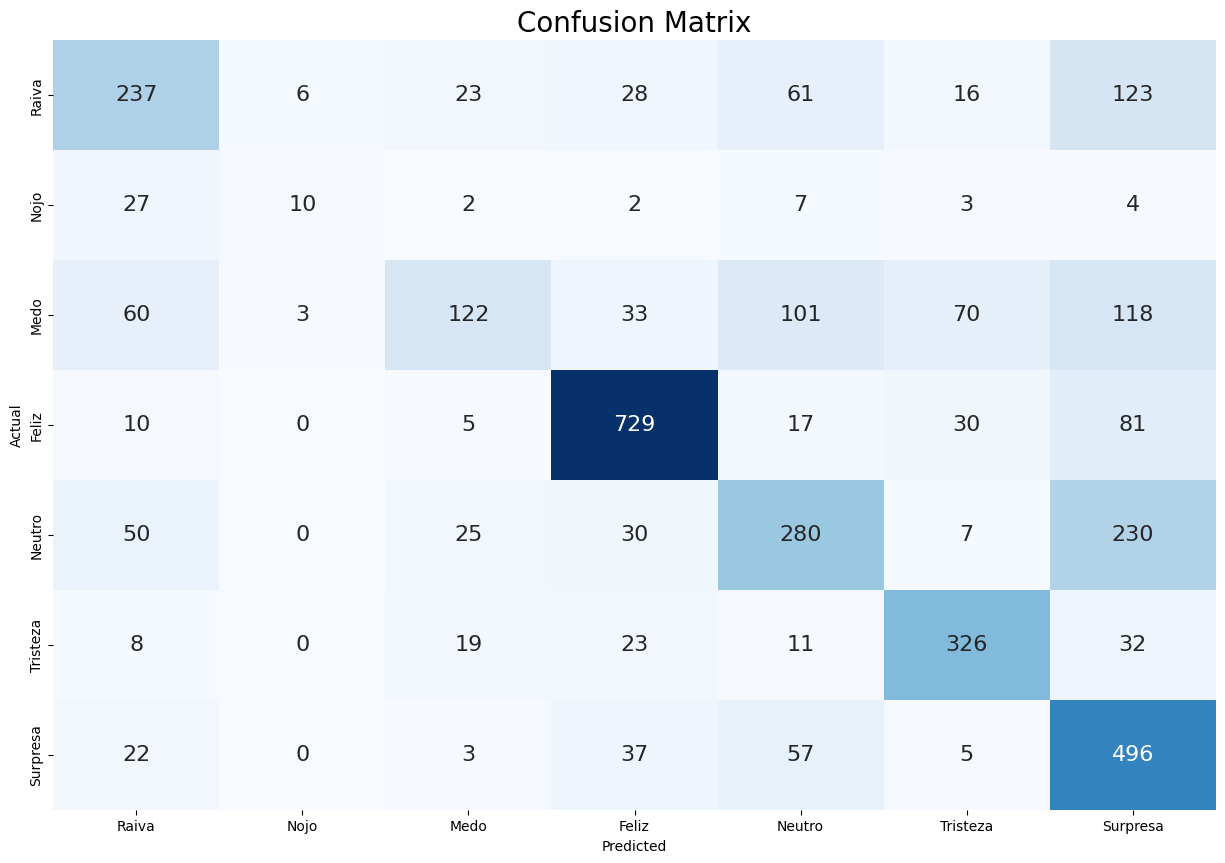

In [ ]:
CLASS_LABELS = ['Raiva', 'Nojo', 'Medo', 'Feliz', 'Neutro', 'Tristeza', "Surpresa"]

cm_data = confusion_matrix(np.argmax(y_test, axis = 1 ), y_pred)
cm = pd.DataFrame(cm_data, columns=CLASS_LABELS, index = CLASS_LABELS)
cm.index.name = 'Actual'
cm.columns.name = 'Predicted'
plt.figure(figsize = (15,10))
plt.title('Confusion Matrix', fontsize = 20)
sns.set(font_scale=1.2)
ax = sns.heatmap(cm, cbar=False, cmap="Blues", annot=True, annot_kws={"size": 16}, fmt='g')

### **Explicação**
- Exibe a **matriz de confusão** para avaliar o desempenho do modelo em diferentes classes.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(np.argmax(y_test, axis = 1 ),y_pred,digits=3))

              precision    recall  f1-score   support

           0      0.572     0.480     0.522       494
           1      0.526     0.182     0.270        55
           2      0.613     0.241     0.346       507
           3      0.827     0.836     0.831       872
           4      0.524     0.450     0.484       622
           5      0.713     0.778     0.744       419
           6      0.458     0.800     0.582       620

    accuracy                          0.613      3589
   macro avg      0.605     0.538     0.540      3589
weighted avg      0.627     0.613     0.598      3589



### **Explicação**
- Exibe um **relatório de classificação** com precisão, recall, F1-score e suporte para cada classe.

Mudando o otimizador... Nem sempre uma mudança implica em melhorias no modelo...

In [ ]:
model = cnn_model()

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(0.001),
                loss='categorical_crossentropy',
                metrics = ['accuracy'])

In [ ]:
with tf.device('/GPU:0'):
  history = model.fit(train_generator,
                      epochs=30,
                      batch_size=64,
                      verbose=1,
                      callbacks=[checkpointer],
                      validation_data=val_generator)

Epoch 1/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.1589 - loss: 14.9860
Epoch 1: val_accuracy did not improve from 0.61207
455/455 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - accuracy: 0.1589 - loss: 14.9856 - val_accuracy: 0.1718 - val_loss: 14.1522
Epoch 2/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1714 - loss: 14.5045
Epoch 2: val_accuracy did not improve from 0.61207
455/455 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.1714 - loss: 14.5043 - val_accuracy: 0.2012 - val_loss: 13.8411
Epoch 3/30
455/455 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1816 - loss: 14.1424
Epoch 3: val_accuracy did not improve from 0.61207
455/455 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.1816 - loss: 14.1422 - val_accuracy: 0.2362 - val_loss: 13.5625
Epoch 4/30
454/455 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.1853 - loss: 13.8424
Epoch 4: val_accuracy did not improve from 0.61207
455/455 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.1853 - loss: 13.8421 - v

In [ ]:
loss = model.evaluate(X_test,y_test)
print("Test Acc: " + str(loss[1]))

105/113 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2759 - loss: 11.1704

In [ ]:
plt.plot(history.history["loss"],'r', label="Training Loss")
plt.plot(history.history["val_loss"],'b', label="Validation Loss")
plt.legend()

In [ ]:
plt.plot(history.history["accuracy"],'r',label="Training Accuracy")
plt.plot(history.history["val_accuracy"],'b',label="Validation Accuracy")
plt.legend()

**SUGESTÃO**  
Alterar o numero de épocas